# v4.8 — RoPE + tokenizador de vocabulario reducido

Misma configuración experimental que v4.6: datos locales, validación, scheduler coseno, W&B, benchmarks y gráfico. Las únicas diferencias son RoPE y el tokenizador SentencePiece Parameter Golf de 16.384 tokens.

In [1]:
%pip install -q wandb matplotlib sentencepiece huggingface_hub


Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path
import sys
import time
import subprocess
import matplotlib.pyplot as plt
import wandb

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", f"{PROJECT_ROOT}[training,benchmarks]"])
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from llm_mini_lab.models import LoopedGPTModel, count_transformer_parameters
from llm_mini_lab.training import (
    LOOPED_GPT_CONFIG, LocalTextDataset, cosine_lr_multiplier, evaluate, generate_text_simple, init_xavier,
    load_tokenizer, text_to_token_ids, token_ids_to_text, tokenizer_vocab_size,
)
from llm_mini_lab.evaluation import evaluate_benchmark_suite

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Proyecto: {PROJECT_ROOT}\nDispositivo: {device}")


Proyecto: /workspace/50M_LLM
Dispositivo: cuda


## Tokenizador

Descarga primero `fineweb_16384_bpe.model` del dataset de Hugging Face y colócalo en `tokenizers/`. También puedes cambiar la ruta en la siguiente celda.

In [2]:
TOKENIZER_NAME = "sp16384"  # Alternativas: "sp16384" o "gpt2"
TOKENIZER_MODEL = PROJECT_ROOT / "tokenizers" / "fineweb_16384_bpe.model"
print(TOKENIZER_MODEL)
if TOKENIZER_NAME == "sp16384" and not TOKENIZER_MODEL.is_file():
    raise FileNotFoundError(
        f"Falta {TOKENIZER_MODEL}. Descárgalo desde Natooka/parameter-golf-sp-tokenizers."
    )

tokenizer = load_tokenizer(
    TOKENIZER_NAME, TOKENIZER_MODEL if TOKENIZER_NAME == "sp16384" else None
)
VOCAB_SIZE = tokenizer_vocab_size(tokenizer)
print(f"Tokenizador: {TOKENIZER_NAME} | vocabulario: {VOCAB_SIZE:,}")


/workspace/50M_LLM/tokenizers/fineweb_16384_bpe.model
Tokenizador: sp16384 | vocabulario: 16,384


In [3]:
# Hiperparámetros: reduce BATCH_SIZE o MAX_LENGTH si no cabe en la GPU.
SEED = 123
MAX_LENGTH = 128
BATCH_SIZE = 2
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.1
MAX_TOKENS = 1_000_000
MAX_UPDATES = MAX_TOKENS // (BATCH_SIZE * MAX_LENGTH)
EVAL_INTERVAL = 10
VAL_BATCHES = 10

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


## Datos locales

Se esperan `train.txt` y `validation.txt` en `data/smollm_local/`. Cada archivo contiene texto UTF-8 sin tokenizar.

In [4]:
DATA_DIR = PROJECT_ROOT / "data" / "smollm_local"
train_path = DATA_DIR / "train.txt"
validation_path = DATA_DIR / "validation.txt"
if not train_path.is_file() or not validation_path.is_file():
    raise FileNotFoundError(f"Crea {train_path} y {validation_path} antes de entrenar.")

train_dataset = LocalTextDataset(train_path, MAX_LENGTH, encoder=tokenizer)
val_dataset = LocalTextDataset(validation_path, MAX_LENGTH, encoder=tokenizer)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
print(f"Bloques: train={len(train_dataset):,}, validación={len(val_dataset):,}")


Bloques: train=7,116, validación=740


In [5]:
cfg = {
    **LOOPED_GPT_CONFIG,
    "context_length": MAX_LENGTH,
    "vocab_size": VOCAB_SIZE,
    "positional_encoding": "rope",
    "tokenizer_name": TOKENIZER_NAME,
    "n_unique_layers": 3,
    "n_heads": 8,
    "emb_dim": 1024
}
model = LoopedGPTModel(cfg).to(device)
model.apply(init_xavier)
model.out_head.weight = model.tok_emb.weight

n_params = sum(p.numel() for p in model.parameters())
assert n_params <= 50_000_000, f"El modelo excede el límite: {n_params:,}"
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
print(f"Parámetros: {n_params:,} ({n_params / 1e6:.2f}M)")


Parámetros: 42,070,080 (42.07M)


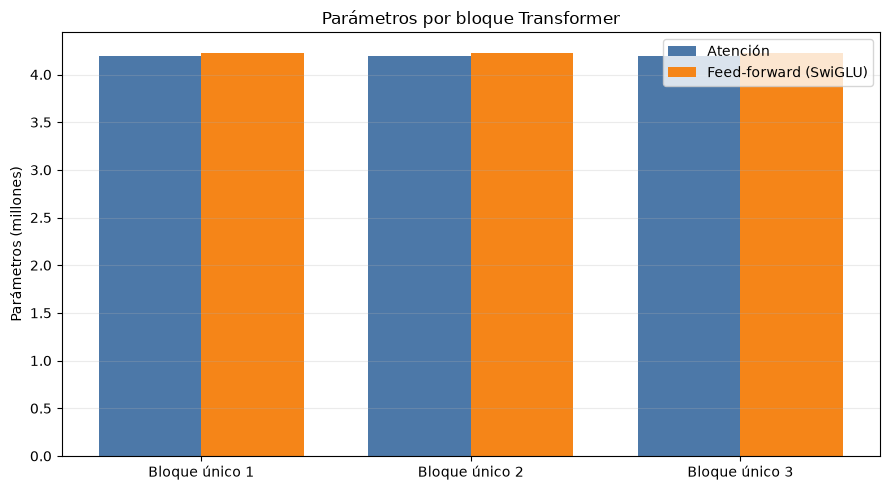

Atención total: 12,585,984
Feed-forward total: 12,692,544


In [6]:
# Desglose de parámetros por bloque Transformer único.
# En LoopedGPTModel los pesos se reutilizan en cada bucle y no se cuentan de nuevo.
desglose = count_transformer_parameters(model)
bloques = range(len(desglose["attention_per_block"]))
ancho = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    [i - ancho / 2 for i in bloques],
    [p / 1e6 for p in desglose["attention_per_block"]],
    width=ancho, label="Atención", color="#4C78A8",
)
ax.bar(
    [i + ancho / 2 for i in bloques],
    [p / 1e6 for p in desglose["feedforward_per_block"]],
    width=ancho, label="Feed-forward (SwiGLU)", color="#F58518",
)
ax.set(
    xticks=list(bloques),
    xticklabels=[f"Bloque único {i + 1}" for i in bloques],
    ylabel="Parámetros (millones)",
    title="Parámetros por bloque Transformer",
)
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Atención total: {desglose['attention_total']:,}")
print(f"Feed-forward total: {desglose['feedforward_total']:,}")


In [7]:
run = wandb.init(
    project="gpt2-50M", name="v4.8-rope-gpt_2_sp_more_embd_dim",
    config={**cfg, "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE, "max_updates": MAX_UPDATES},
)
wandb.define_metric("update")
wandb.define_metric("*", step_metric="update")
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lambda step: cosine_lr_multiplier(step, max(1, int(0.05 * MAX_UPDATES)), MAX_UPDATES, 0.1)
)
BENCHMARK_EVAL_FREQ, BENCHMARK_MAX_EXAMPLES = 50, 25
BENCHMARK_NAMES = ("hellaswag", "arc_easy", "piqa", "winogrande")
train_losses, val_losses, val_steps = [], [], []
tokens_seen = update = epoch = 0
model.train()
t0 = time.perf_counter()
while update < MAX_UPDATES:
    epoch += 1
    for inputs, targets in train_loader:
        update += 1
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = F.cross_entropy(logits.flatten(0, 1), targets.flatten())
        if not torch.isfinite(loss):
            raise FloatingPointError(f"Pérdida no finita en el paso {update}")
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_losses.append(loss.item())
        tokens_seen += inputs.numel()
        wandb.log({"update": update, "tokens_seen": tokens_seen, "train/loss": loss.item(), "train/lr": optimizer.param_groups[0]["lr"], "train/grad_norm": grad_norm.item()})
        if update % EVAL_INTERVAL == 0:
            mean_val_loss = evaluate(model, val_loader, VAL_BATCHES, device)
            val_steps.append(update); val_losses.append(mean_val_loss)
            wandb.log({"update": update, "validation/loss": mean_val_loss})
            print(f"Step {update:04d}/{MAX_UPDATES} | train {loss.item():.4f} | val {mean_val_loss:.4f}")
        if update % BENCHMARK_EVAL_FREQ == 0:
            results = evaluate_benchmark_suite(model, tokenizer, device, names=BENCHMARK_NAMES, max_examples=BENCHMARK_MAX_EXAMPLES, context_length=MAX_LENGTH)
            wandb.log({"update": update, **{f"benchmark/{name}_accuracy": metrics["accuracy"] for name, metrics in results.items()}})
        if update >= MAX_UPDATES:
            break
print(f"Entrenamiento: {tokens_seen:,} tokens en {epoch} época(s), {time.perf_counter() - t0:.1f}s")


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: volverman22 (volverman22-universidad-aut-noma-de-madrid) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step 0010/3906 | train 9.7628 | val 9.7506
Step 0020/3906 | train 9.7796 | val 9.7128
Step 0030/3906 | train 9.6349 | val 9.6394
Step 0040/3906 | train 9.3770 | val 9.4117
Step 0050/3906 | train 9.0737 | val 8.8337


Step 0060/3906 | train 8.3408 | val 8.1849
Step 0070/3906 | train 7.6892 | val 7.7009
Step 0080/3906 | train 7.3100 | val 7.4907
Step 0090/3906 | train 7.3379 | val 7.4247
Step 0100/3906 | train 7.2779 | val 7.4029
Step 0110/3906 | train 7.4247 | val 7.4035
Step 0120/3906 | train 7.2043 | val 7.4036
Step 0130/3906 | train 7.7964 | val 7.3825
Step 0140/3906 | train 7.0156 | val 7.3764
Step 0150/3906 | train 7.5470 | val 7.3490
Step 0160/3906 | train 7.5275 | val 7.3310
Step 0170/3906 | train 7.2430 | val 7.3367
Step 0180/3906 | train 7.2337 | val 7.3309
Step 0190/3906 | train 7.3263 | val 7.3028
Step 0200/3906 | train 7.1481 | val 7.2766
Step 0210/3906 | train 7.2116 | val 7.2440
Step 0220/3906 | train 7.1742 | val 7.2010
Step 0230/3906 | train 7.2908 | val 7.1809
Step 0240/3906 | train 7.1131 | val 7.1100
Step 0250/3906 | train 7.0113 | val 7.0962
Step 0260/3906 | train 7.0499 | val 7.0952
Step 0270/3906 | train 7.0966 | val 7.0756
Step 0280/3906 | train 6.9736 | val 7.0284
Step 0290/3

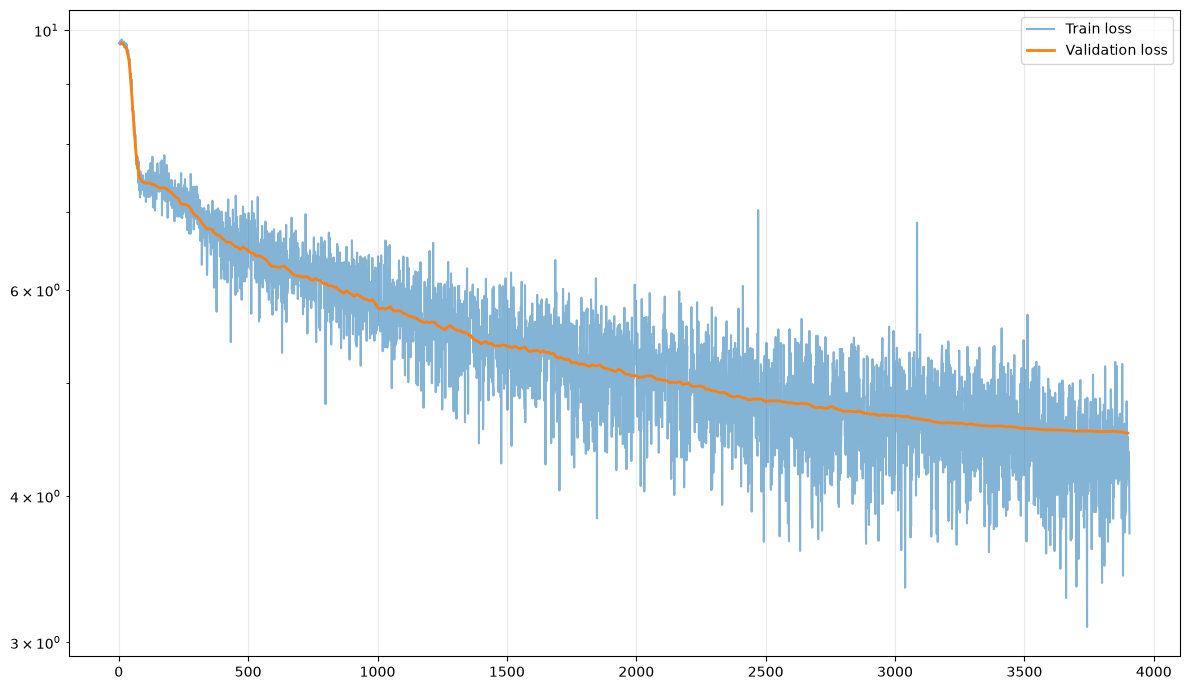

Artificial intelligence, theory of theory, and theory of theory, theory of theory, and theory, and theory of theory, and theory of theory, theory


wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


benchmark/arc_easy_accuracy,▃▆▇█▇▄▄▄▄▃▄▂▄▃▃▅▃▆▄▃▄▂▃▃▄▂▃▃▂▂▃▁▂▂▃▃▃▃▃▃
benchmark/hellaswag_accuracy,▅▆▅█▅▆▅▁▁▁▃▃▃▃▆▃▁▃▃▅▁▅▃▃▁▁▁▃▃▃▃▁▁▁▁▁▁▁▁▁
benchmark/piqa_accuracy,▄▅▇▄▁▅▄▁▅▂▅▅▅█▁▅▁▂▇▄▂▂▄▂▂▄▄▅▄▄▂▄▅▂▂▂▂▂▄▄
benchmark/winogrande_accuracy,▆█▆▄▃▄▄█▃▄▃▃█▆█▁▄▆▄▆▄▄▄▃▆▁▄▃▃▄▄▃▄▄▃▃▄▄▃▃
tokens_seen,▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇███
train/grad_norm,█▁▂▃▂▃▃▄▃▃▂▃▃▃▃▃▃▂▃▃▃▂▂▃▂▃▂▂▃▄▂▃▃▃▂▃▃▅▃▃
train/loss,█▇▇▆▄▆▅▅▄▄▅▄▄▄▄▃▂▃▄▂▄▃▃▂▂▂▂▂▂▂▃▁▁▂▁▃▂▂▂▁
train/lr,▂▂▅▇▇██████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁
update,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇▇▇▇▇▇█
validation/loss,█▇▇▇▆▆▆▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
benchmark/arc_easy_accuracy,0.24


Checkpoint guardado en: /workspace/50M_LLM/checkpoints/v4.8_sp16384.pt


In [8]:
plt.figure(figsize=(12, 7))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train loss", alpha=0.55)
plt.plot(val_steps, val_losses, linewidth=2, label="Validation loss")
plt.yscale("log"); plt.grid(alpha=0.25); plt.legend(); plt.tight_layout(); plt.show()

model.eval()
prompt = text_to_token_ids("Artificial intelligence", tokenizer).to(device)
sample_ids = generate_text_simple(model, prompt, max_new_tokens=40, context_size=MAX_LENGTH)
print(token_ids_to_text(sample_ids.cpu(), tokenizer))

checkpoint_path = PROJECT_ROOT / "checkpoints" / f"v4.8_{TOKENIZER_NAME}.pt"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": cfg,
    "tokenizer_model": str(TOKENIZER_MODEL) if TOKENIZER_NAME == "sp16384" else None,
    "updates": update, "tokens_seen": tokens_seen,
    "train_losses": train_losses, "val_steps": val_steps, "val_losses": val_losses,
}, checkpoint_path)
run.save(str(checkpoint_path))
run.finish()
print(f"Checkpoint guardado en: {checkpoint_path}")
